<a href="https://colab.research.google.com/github/oliviapang/demand_estimation_project/blob/main/1_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1: Data Analysis**

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [25]:
df = pd.read_csv('/content/undergrad_ml_assignments/demand_est_project/air_fryers_clean_brand_year.csv')

**1. Verify that the data contain 10 brands and the years 2019-2023.**

In [26]:
print(df.shape)
print(df.head())

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

In [27]:
print(df['brand'].unique())
print(df['year'].unique())

['chefman' 'cosori' 'cuisinart' 'dash' 'gowise usa' 'instant_pot' 'ninja'
 'nuwave' 'oster' 'ultrean']
[2019 2020 2021 2022 2023]


There are 10 brands: Chefman, Cosori, Cuisinart, Dash, Gowise USA, Instant Pot, Ninja, Nuwave, Oster, and Ultrean.
There are five years, spanning from 2019 to 2023.

**2. Plot the following over time by brand: average price, average rating, brand market share**

<Axes: xlabel='year', ylabel='avg_price'>

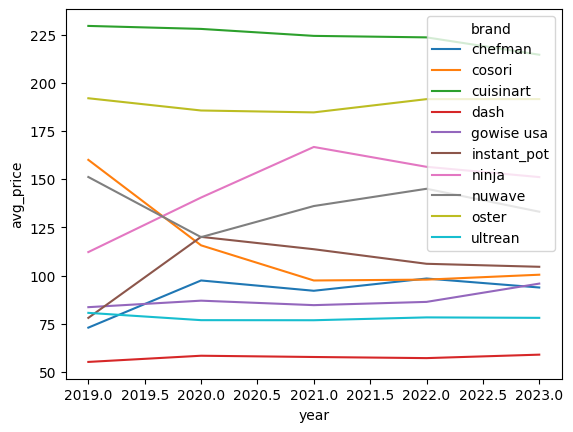

In [48]:
sns.lineplot(x = df['year'], y = df['avg_price'], hue = df['brand'])

<Axes: xlabel='year', ylabel='avg_rating'>

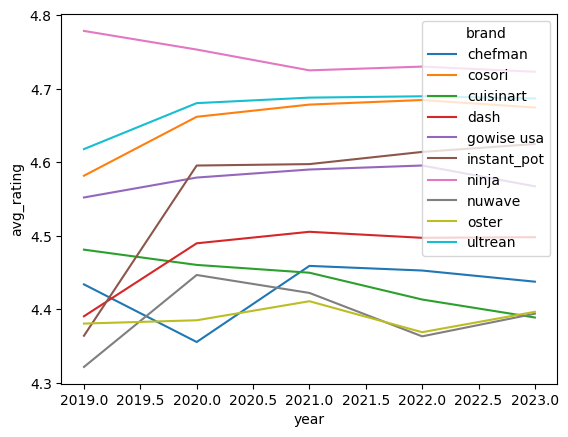

In [49]:
sns.lineplot(x = df['year'], y = df['avg_rating'], hue = df['brand'])

<Axes: xlabel='year', ylabel='brand_share'>

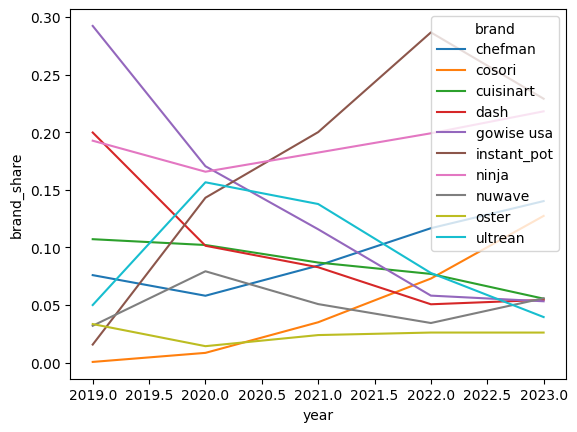

In [50]:
sns.lineplot(x = df['year'], y = df['brand_share'], hue = df['brand'])

**3. Summarize the product characteristics: Which features are common? Which features are rare? Are there brands that seem to specialize in different product types?**

In [40]:
df.columns
features = ['compact_share', 'dual_basket_share',
       'oven_style_share', 'rotisserie_share', 'window_share']

In [43]:
df[features].mean().sort_values()

,0
dual_basket_share,0.002260
window_share,0.036741
rotisserie_share,0.070762
oven_style_share,0.562647
compact_share,0.980081


In [47]:
df.groupby('brand')[features].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


The most common features are compact and oven style, as over half of the airfyers on the market posses those features. The rotisserie, window, and dual basket features are more rare; any one of these rare features is found in less than 10% of the products on the market. Cuisinart, Dash, Oster, and Ultrean specialize in oven style products. Chefman stands out as the only brand having a significant share of products with the rotisserie and window share. Cosori, Gowise USA, and Ninja all have low shares in oven style, indiciating that they probabily specialize in more standard setup air fryers.

**4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?**

In the air fryer market, Cuisinart maintains a fairly constant average price at the top of the price range, followed by Oster; Dash consistently has the lowest price. Ultrean and Gowise USA also remain on the lower end of the price range. From around 2019-2020 Cosori and Nuwave have higher average prices than Ninja and Instant Pot; however, these two pairs switch places after 2020. Ninja has the highest ranking across all years, followed by Ultrean and Cosori. Interestingly, some of the most expensive brands (e.g. Oster and Cuisinart) have some of the lowest average ratings across all years. In 2019, Gowise made up nearly 30% of the air fryer market. However, this share dropped steadily through 2023, where it makes up about 15%. In contrast, Instant Pot holds a small share in 2019 but climbs to nearly 30% in 2022. As of 2023, Instant Pot and Ninja dominate the market. Overall, the market appears relatively unstable. Barring a couple brands (Ninja, Oster, and potentially Nuwave), market shares change pretty drasticlly, indicating changes in consumer preference and brand competition.